# Task 3 — Clasificarea automată a produselor
**Andrei Motau**

Obiectiv: sugerarea categoriei folosind doar titlul produsului. Notebook-ul documentează analiza, ingineria caracteristicilor, selecția modelului și testarea. Scriptul `train_model.py` centralizează logica pentru ca notebook-ul și antrenarea din terminal să fie identice.

Rulează din folderul proiectului după instalarea `requirements.txt`. Pentru Colab, încarcă și dezarhivează întregul proiect, apoi schimbă directorul curent în folderul care conține `train_model.py`. Notebook-ul este livrat cu rezultate executate.

In [1]:
from pathlib import Path
import json, pickle
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from train_model import load_data, train, candidates, title_stats
ROOT = Path.cwd()
assert (ROOT / 'products.csv').exists(), 'Deschide notebook-ul din folderul proiectului.'
raw, data, quality = load_data(ROOT / 'products.csv')
display(raw.head())
print('Dimensiuni:', raw.shape)
display(raw.dtypes.to_frame('tip'))
display(raw.isna().sum().to_frame('valori lipsă'))
print(json.dumps(quality, indent=2, ensure_ascii=False))

Dimensiuni: (35311, 8)
{
  "raw_rows": 35311,
  "missing_by_column": {
    "product ID": 0,
    "Product Title": 172,
    "Merchant ID": 0,
    "Category Label": 44,
    "_Product Code": 95,
    "Number_of_Views": 14,
    "Merchant Rating": 170,
    "Listing Date": 59
  },
  "missing_or_empty_required": 215,
  "conflicting_titles": 2,
  "conflicting_rows_removed": 4,
  "duplicates_removed": 4270,
  "clean_rows": 30822
}


,product ID,Product Title,Merchant ID,Category Label,_Product Code,Number_of_Views,Merchant Rating,Listing Date
0,1,apple iphone 8 plus 64gb silver,1,Mobile Phones,QA-2276-XC,860.0,2.5,5/10/2024
1,2,apple iphone 8 plus 64 gb spacegrau,2,Mobile Phones,KA-2501-QO,3772.0,4.8,12/31/2024
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,Mobile Phones,FP-8086-IE,3092.0,3.9,11/10/2024
3,4,apple iphone 8 plus 64gb space grey,4,Mobile Phones,YI-0086-US,466.0,3.4,5/2/2022
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,Mobile Phones,NZ-3586-WP,4426.0,1.6,4/12/2023


,tip
product ID,int64
Product Title,object
Merchant ID,int64
Category Label,object
_Product Code,object
Number_of_Views,float64
Merchant Rating,float64
Listing Date,object


,valori lipsă
product ID,0
Product Title,172
Merchant ID,0
Category Label,44
_Product Code,95
Number_of_Views,14
Merchant Rating,170
Listing Date,59


## Curățarea și alegerea intrărilor
Numele coloanelor conțin spații inutile; le elimin. Elimin rândurile fără titlu sau categorie și uniformizez spațiile. `CPU` devine `CPUs`, `Mobile Phone` devine `Mobile Phones`, iar `fridge` devine `Fridges`. Nu combin `Fridges`, `Freezers` și `Fridge Freezers`, fiind clase distincte.

Elimin titlurile identice (după lowercase și uniformizarea spațiilor) înainte de split. Dacă un titlu păstrează etichete contradictorii după normalizare, exclud toate aparițiile lui: nu inventez eticheta corectă. Numerele efective sunt afișate mai sus.

ID-urile, codurile, vizualizările, ratingul și data nu sunt folosite: la predicție utilizatorul oferă doar titlul. Valorile lipsă din aceste coloane sunt raportate, dar nu necesită imputare pentru acest model. Fișierul original rămâne nemodificat.

,produse unice
Category Label,
Fridge Freezers,4808
Mobile Phones,3662
Washing Machines,3402
TVs,3275
Fridges,3188
CPUs,3043
Dishwashers,3042
Digital Cameras,2405
Microwaves,2094


,caractere,cuvinte,cifre,simboluri
count,30822.00,30822.00,30822.00,30822.00
mean,52.76,8.65,6.82,0.29
std,22.62,4.22,4.43,0.62
min,5.00,1.00,0.00,0.00
25%,38.00,6.00,4.00,0.00
50%,51.00,8.00,6.00,0.00
75%,65.00,11.00,9.00,0.00
max,200.00,37.00,54.00,9.00


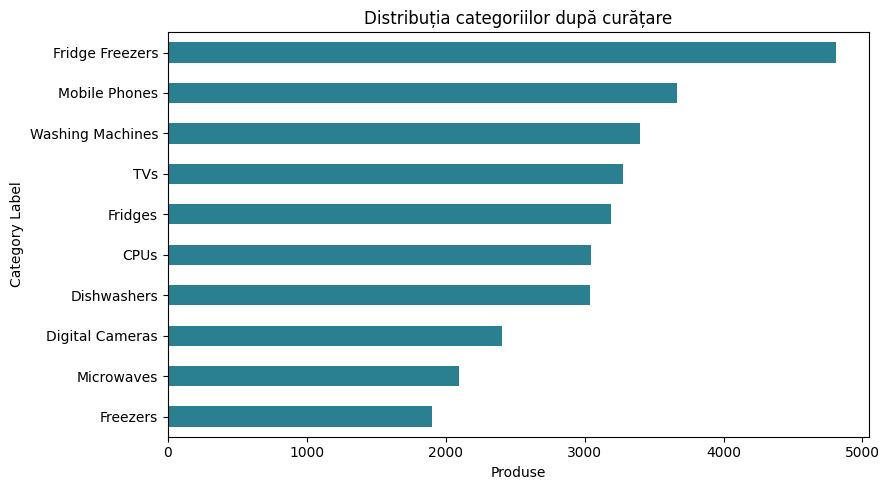

In [2]:
counts=data['Category Label'].value_counts()
display(counts.to_frame('produse unice'))
counts.sort_values().plot.barh(figsize=(9,5),color='#2a7f91')
plt.title('Distribuția categoriilor după curățare');plt.xlabel('Produse');plt.tight_layout();plt.show()
stats=pd.DataFrame(title_stats(data['Product Title']),columns=['caractere','cuvinte','cifre','simboluri'])
display(stats.describe().round(2))

## Ingineria caracteristicilor și experimente
Compar cinci configurații fixe:
1. TF-IDF pe cuvinte și bigrame + MultinomialNB: baseline probabilistic.
2. Aceleași caracteristici + LogisticRegression.
3. Aceleași caracteristici + LinearSVC.
4. TF-IDF `char_wb`, secvențe de 3–5 caractere + LinearSVC: poate recunoaște fragmente de coduri și variații ortografice.
5. TF-IDF cuvinte + lungimea titlului, numărul de cuvinte, cifre și simboluri + LinearSVC. Caracteristicile numerice sunt scalate cu MaxAbsScaler și ponderate cu 0,2, pentru a nu domina textul.

Vocabularul este limitat la 50.000 de caracteristici pentru cuvinte, respectiv 60.000 pentru caractere, pentru consum de memorie controlat. `min_df=2` reduce termenii extrem de rari. Nu elimin numerele și nu folosesc o listă de stopwords, deoarece datele conțin titluri comerciale în mai multe limbi.

## Protocol de evaluare
Împărțire stratificată și reproductibilă (seed 42): **60% train, 20% validare, 20% test**. Toate transformările care învață sunt în Pipeline și sunt ajustate exclusiv pe train la comparație. Aleg câștigătorul după **F1 macro pe validare**, apoi accuracy la egalitate. F1 macro acordă greutate egală fiecărei categorii.

Reantrenez configurația aleasă pe train+validare (80%) și evaluez o singură dată pe test. După evaluare, salvez un model de utilizare antrenat pe toate datele curate. Scorurile testului nu sunt scoruri ale modelului reantrenat pe 100%.

In [3]:
# Aceeași funcție este utilizată de comanda python train_model.py.
raw, data, comparison, metrics, model = train(ROOT / 'products.csv', ROOT)
display(comparison.round(4))

{'model': 'word_nb', 'accuracy': 0.9429034874290348, 'macro_f1': 0.9439161300197952}
{'model': 'word_lr', 'accuracy': 0.9502027575020275, 'macro_f1': 0.9512509175762643}
{'model': 'word_svc', 'accuracy': 0.959448499594485, 'macro_f1': 0.9604541696481945}
{'model': 'char_svc', 'accuracy': 0.9873479318734794, 'macro_f1': 0.9871436699885388}
{'model': 'word_stats_svc', 'accuracy': 0.9592862935928629, 'macro_f1': 0.9602572003604417}
{
  "quality": {
    "raw_rows": 35311,
    "missing_by_column": {
      "product ID": 0,
      "Product Title": 172,
      "Merchant ID": 0,
      "Category Label": 44,
      "_Product Code": 95,
      "Number_of_Views": 14,
      "Merchant Rating": 170,
      "Listing Date": 59
    },
    "missing_or_empty_required": 215,
    "conflicting_titles": 2,
    "conflicting_rows_removed": 4,
    "duplicates_removed": 4270,
    "clean_rows": 30822
  },
  "split": {
    "train": 18492,
    "validation": 6165,
    "test": 6165
  },
  "winner": "char_svc",
  "test_accur

,model,accuracy,macro_f1
3,char_svc,0.9873,0.9871
2,word_svc,0.9594,0.9605
4,word_stats_svc,0.9593,0.9603
1,word_lr,0.9502,0.9513
0,word_nb,0.9429,0.9439


Model selectat: char_svc
Accuracy test: 98.99%
F1 macro test: 99.01%
Baseline clasa majoritară: 15.60%


,precision,recall,f1-score,support
CPUs,1.0000,0.9951,0.9975,609.0000
Digital Cameras,0.9959,1.0000,0.9979,481.0000
Dishwashers,0.9967,0.9967,0.9967,608.0000
Freezers,0.9867,0.9738,0.9802,381.0000
Fridge Freezers,0.9834,0.9844,0.9839,962.0000
Fridges,0.9598,0.9718,0.9657,638.0000
Microwaves,0.9976,0.9905,0.9940,419.0000
Mobile Phones,0.9973,0.9945,0.9959,732.0000
TVs,0.9954,0.9985,0.9970,655.0000
Washing Machines,0.9926,0.9926,0.9926,680.0000


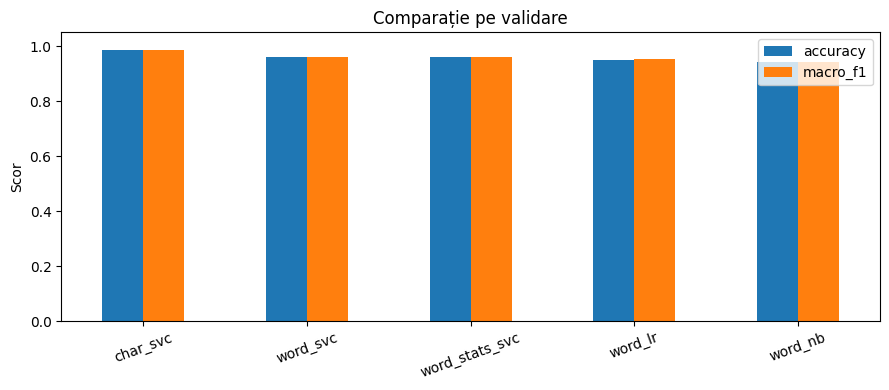

In [4]:
comparison.set_index('model')[['accuracy','macro_f1']].plot.bar(figsize=(9,4),rot=20,ylim=(0,1.05))
plt.title('Comparație pe validare');plt.ylabel('Scor');plt.xlabel('');plt.tight_layout();plt.show()
print('Model selectat:', metrics['winner'])
print(f"Accuracy test: {metrics['test_accuracy']:.2%}")
print(f"F1 macro test: {metrics['test_macro_f1']:.2%}")
print(f"Baseline clasa majoritară: {metrics['majority_baseline']:.2%}")
report=pd.read_csv('classification_report.csv',index_col=0)
display(report.round(4))

Erori: 62


,Product Title,Category Label,prediction
0,zanussi zwy61225wi eek a skala a bis d zwy61225wi,Washing Machines,Fridges
1,bosch stand k hlger t gsn36bi30,Freezers,Fridges
2,amica ziv635,Dishwashers,Fridge Freezers
3,zanussi zbt20420sa 122cm doppeltrger t eek a s...,Fridge Freezers,Fridges
4,cda fw321/fw321,Fridges,Fridge Freezers
5,siemens ki28da20 eingebaut 255l a wei k hl,Fridge Freezers,Fridges
6,smeg fab5rpk fridge freezer,Fridges,Fridge Freezers
7,liebherr bp2850 white biofresh fridge freezer,Fridges,Fridge Freezers
8,miele kf 37122 id eingebaut 287l a wei,Fridge Freezers,Fridges
9,bosch k hlschrank integrierbar kin86af30,Fridge Freezers,Fridges


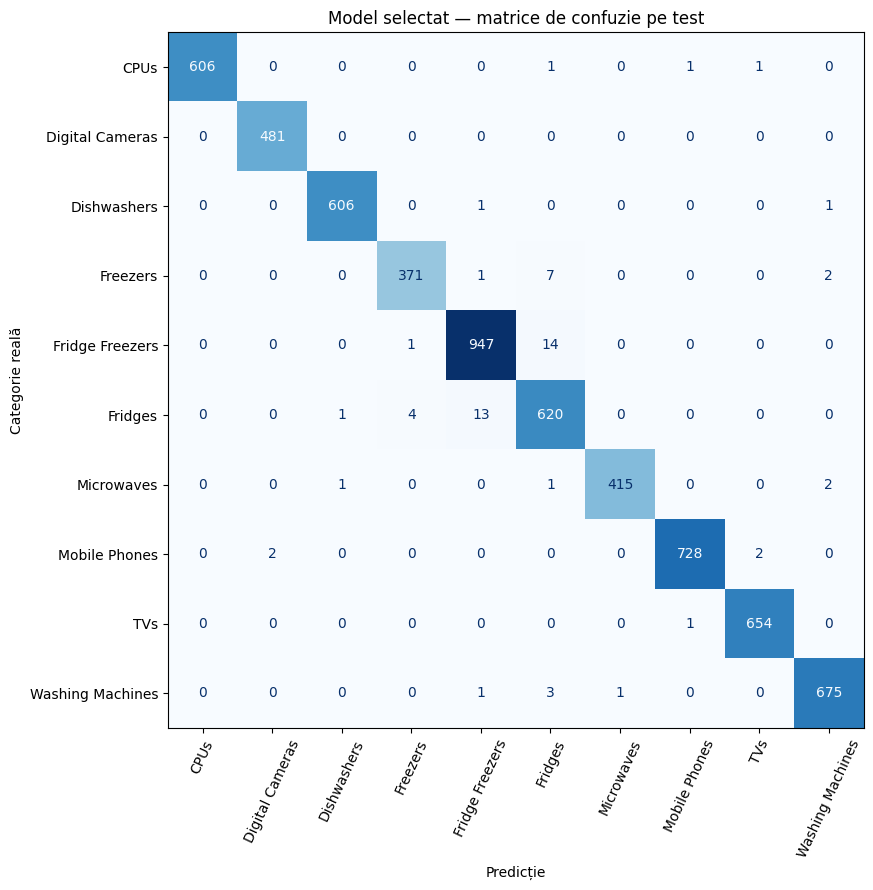

In [5]:
from sklearn.metrics import ConfusionMatrixDisplay
cm=pd.read_csv('confusion_matrix.csv',index_col=0)
fig,ax=plt.subplots(figsize=(11,9))
ConfusionMatrixDisplay(cm.values,display_labels=cm.index).plot(ax=ax,cmap='Blues',xticks_rotation=65,colorbar=False,values_format='d')
ax.set_title('Model selectat — matrice de confuzie pe test')
ax.set_xlabel('Predicție');ax.set_ylabel('Categorie reală')
plt.tight_layout();plt.show()
errors=pd.read_csv('test_errors.csv')
print('Erori:',len(errors))
display(errors.head(12))

## Salvare, reîncărcare și exemplele din cerință
`product_model.pkl` include vectorizarea și clasificatorul, nu doar coeficienții. Scriptul de antrenare verifică egalitatea predicțiilor înainte și după salvare. La încărcare păstrează `train_model.py` lângă model, deoarece varianta cu statistici poate folosi funcția definită în acest modul.

Exemplele de mai jos sunt verificări funcționale, nu un test independent: unele titluri pot exista în date. Predicțiile sunt obținute de model, fără reguli scrise special pentru exemple.

In [6]:
examples=pd.DataFrame({
 'title':['iphone 7 32gb gold,4,3,Apple iPhone 7 32GB','olympus e m10 mark iii geh use silber','kenwood k20mss15 solo','bosch wap28390gb 8kg 1400 spin','bosch serie 4 kgv39vl31g','smeg sbs8004po'],
 'expected':['Mobile Phones','Digital Cameras','Microwaves','Washing Machines','Fridge Freezers','Fridge Freezers']})
with open('product_model.pkl','rb') as f:loaded=pickle.load(f)
examples['predicted']=loaded.predict(examples.title)
examples['correct']=examples.expected.eq(examples.predicted)
display(examples)
examples.to_csv('example_predictions.csv',index=False)
print('Exemple corecte:',int(examples.correct.sum()),'din',len(examples))

Exemple corecte: 6 din 6


,title,expected,predicted,correct
0,"iphone 7 32gb gold,4,3,Apple iPhone 7 32GB",Mobile Phones,Mobile Phones,True
1,olympus e m10 mark iii geh use silber,Digital Cameras,Digital Cameras,True
2,kenwood k20mss15 solo,Microwaves,Microwaves,True
3,bosch wap28390gb 8kg 1400 spin,Washing Machines,Washing Machines,True
4,bosch serie 4 kgv39vl31g,Fridge Freezers,Fridge Freezers,True
5,smeg sbs8004po,Fridge Freezers,Fridge Freezers,True


## Concluzii și limite
Câștigătorul este determinat din validare, fără consultarea testului. Tabelul arată dacă adăugarea statisticilor titlului îmbunătățește efectiv F1 macro față de `word_svc`; o caracteristică suplimentară nu garantează un câștig.

Accuracy măsoară proporția totală de predicții corecte. Precision pe categorie măsoară cât de fiabile sunt sugestiile respective, iar recall arată câte produse din categoria reală sunt recunoscute. Matricea arată perechile confundate și raportul oferă suportul fiecărei clase.

Modelul sugerează una dintre categoriile cunoscute și pentru un produs din afara domeniului; nu are mecanism de detectare a categoriilor necunoscute. Titlurile foarte scurte, codurile noi și mărcile ambigue necesită verificare umană. Duplicate aproape identice și variante ale aceluiași produs pot rămâne între partiții: scorul random-split poate fi optimist pentru modele de produse complet noi. Un pas ulterior ar fi evaluarea pe grupuri de coduri de produs și pe o perioadă ulterioară.

Îmbunătățiri: validare încrucișată pe train/development pentru hiperparametri, analiză pe clase, date suplimentare pentru clase rare și un mecanism de abținere calibrat pe date separate. Nu am ajustat configurațiile după scorul de test.

## Utilizare și predare
`python predict_category.py` pornește interacțiunea; `python train_model.py` reproduce întregul experiment. Instrucțiunile complete sunt în README. Cerința de predare este **linkul repository-ului public GitHub**, după publicarea tuturor fișierelor proiectului. Arhiva locală nu dovedește publicarea.

**Rezultatul rulat:** `char_svc` câștigă pe validare cu F1 macro 98,71%. Pe testul independent are accuracy 98,99%, F1 macro 99,01% și 62 de erori. Varianta cu statistici a obținut F1 macro 96,03%, față de 96,05% pentru cuvinte + SVC, deci nu aduce un câștig în acest experiment. Toate cele șase exemple din enunț au categoria așteptată.